## Goal is to use NLP and machine learning to predict target countries of cyber attacks

Aim: Can the latent topics emerging from the incident descriptions a) predict countries targeted by cyber attacks and b) societal impact above and beyond the incident types already present in the data set (data theft, disruption, hijacking, physical effects (spatial), physical effects (temporal))?

### Hypotheses
H1: Target Countries
Existing categories are broad. BERTopic themes may capture more nuanced operational intent and therefore better predict who gets targeted. BERTopics will outperform existing categories in predicting target countries. 

H2: Impact
BERTopics are more fine-grained than the existing cyber operation categories and may explain additional variance in impact scores. 

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import shap
import pickle

/Users/heather.iriye/Library/CloudStorage/OneDrive-KarolinskaInstitutet/Documents/GitHub/eurepoc_cyber_security-/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load dyadic data
dyadic_data_topic = pd.read_csv(
    "data/eurepoc_dataset/dyadic_data_topics.csv"
)

# original dyadic data
url = "https://zenodo.org/records/14965395/files/eurepoc_dyadic_dataset_0_1.csv?download=1"

dyadic_data_orig = pd.read_csv(url)

In [3]:
# The topic analysis removed topic outliers (assigned -1) and short word descriptions (n < 5)
# Filter dyadic_data_orig so they're the same in order to compare models 
common_ids = set(
    dyadic_data_topic["incident_id"]
)

dyadic_data_orig_matched = dyadic_data_orig[
    dyadic_data_orig["incident_id"].isin(common_ids)
].copy()

print(dyadic_data_topic.shape)
print(dyadic_data_orig_matched.shape)

(2246, 52)
(2246, 57)


# Predicing Impact Intensity 
## Model A: Existing operation categories only

In [4]:
# First, drop countries that only appear a few times in the dataset 
# as they will be very difficult to predict
before = dyadic_data_orig_matched["receiver_country"].nunique()

filtered_orig = dyadic_data_orig_matched.groupby("receiver_country").filter(
    lambda x: len(x) >= 50
)

after = filtered_orig["receiver_country"].nunique()

print(f"Removed {before - after} countries with fewer than 50 observations")

Removed 169 countries with fewer than 50 observations


In [5]:
# Model A: Existing features only 
existing_features = [
    "Data theft",
    "Data theft & Doxing",
    "Hijacking with Misuse",
    "Hijacking without Misuse",
    "Ransomware"
]

control_features = [
    "initiator_country",
    "receiver_country",
    "cyber_conflict_issue",
    "offline_conflict_intensity",
    "affected_entities_value",
    "affected_third_countries_value"
]
 # One-hot encode categorical variables
X_controls = pd.get_dummies(
    filtered_orig[control_features],
    drop_first=True
)

X_existing = pd.concat(
    [
        X_controls,
        filtered_orig[existing_features]
    ],
    axis=1
)

# Fix columns with special characters
X_existing.columns = (
    X_existing.columns
    .astype(str)
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# encode y labels to integers
y = filtered_orig["impact_indicator_score"]

In [6]:
# Split into training and testing data
X_train_A , X_test_A, y_train_A, y_test_A = train_test_split(
    X_existing,
    y,
    test_size=0.2,
    random_state = 99,
)

print(X_train_A.shape)
print(X_test_A.shape)
print(y_train_A.shape)
print(y_test_A.shape)

(659, 66)
(165, 66)
(659,)
(165,)


In [7]:
# Define model
xgbA = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=99
)

# 5-fold CV
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=99
)

# Cross-validation
for metric in [
    "neg_mean_absolute_error",
    "neg_root_mean_squared_error",
    "r2"
]:
    scores = cross_val_score(
        xgbA,
        X_train_A,
        y_train_A,
        cv=cv,
        scoring=metric
    )

    print(metric, np.mean(scores))

neg_mean_absolute_error -1.1328195810317994
neg_root_mean_squared_error -1.8642649888992309
r2 0.7447376132011414


MAE: 1.052
RMSE: 1.876
R²: 0.760
      Actual  Predicted
2067       7   6.196943
2160       6   6.681375
3511       9   9.534100
4089       0  -0.003861
2333       7   7.176196
259        8  -0.187692
2307       7   7.176196
1679       7   8.154620
4145       6   7.639459
3438       6   6.561165
4088       0   1.124351
246        0  -0.554645
1057       0   0.197690
2232       6   6.400376
2147       7   6.681375
2361       7   6.577625
3136       0   0.025587
749        5   6.566453
4197      11  10.071862
610        9   7.830046


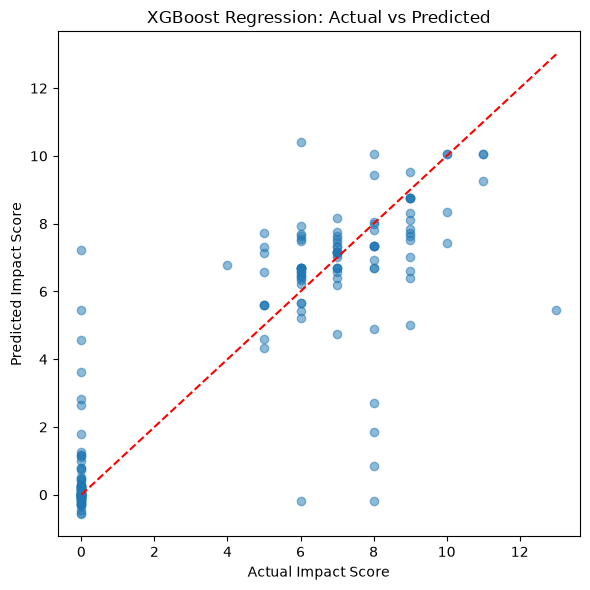

In [8]:
# Fit model
xgbA.fit(X_train_A, y_train_A)

# Predictions
y_pred_A = xgbA.predict(X_test_A)

# Evaluation
mae = mean_absolute_error(y_test_A, y_pred_A)
rmse = mean_squared_error(y_test_A, y_pred_A) ** 0.5
r2 = r2_score(y_test_A, y_pred_A)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

comparison = pd.DataFrame({
    "Actual": y_test_A,
    "Predicted": y_pred_A
})

print(comparison.head(20))

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_A,
    y_pred_A,
    alpha=0.5
)

plt.plot(
    [y_test_A.min(), y_test_A.max()],
    [y_test_A.min(), y_test_A.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Impact Score")
plt.ylabel("Predicted Impact Score")
plt.title("XGBoost Regression: Actual vs Predicted")


plt.tight_layout()
plt.savefig(
    "model_output/impact_score_XGBoost_scatterplot_existing_predictors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

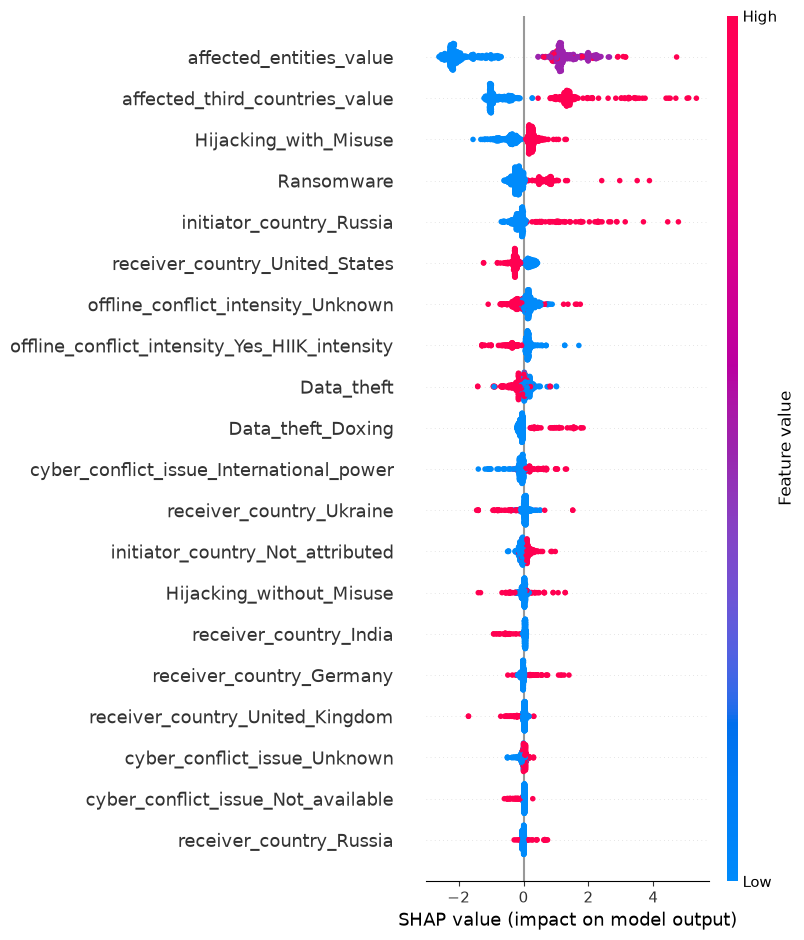

<Figure size 640x480 with 0 Axes>

In [9]:
explainer = shap.TreeExplainer(xgbA)
shap_values = explainer.shap_values(X_train_A)

shap.summary_plot(shap_values, X_train_A)

plt.tight_layout()
plt.savefig(
    "model_output/impact_score_XGBoost_existing_predictors_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)


## Model B: Latent Cyber Operation Topics

In [10]:
# First, drop countries that only appear a few times in the dataset 
# as they will be very difficult to predict
before = dyadic_data_topic["receiver_country"].nunique()

filtered_topic = dyadic_data_topic.groupby("receiver_country").filter(
    lambda x: len(x) >= 50
)

after = filtered_topic["receiver_country"].nunique()

print(f"Removed {before - after} countries with fewer than 50 observations")


Removed 169 countries with fewer than 50 observations


In [12]:
# One-hot encode control variables
X_controls = pd.get_dummies(
    filtered_topic[control_features],
    drop_first=True
)

# One-hot encode BERTopic assignments
X_topics = pd.get_dummies(
    filtered_topic["topic"],
    prefix="topic",
    drop_first=True
)

# Combine controls and topics
X_topic = pd.concat(
    [X_controls, X_topics],
    axis=1
)

# Clean column names for XGBoost
X_topic.columns = (
    X_topic.columns
    .astype(str)
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# Encode y labels
y = filtered_orig["impact_indicator_score"]

In [13]:
# Split into training and testing data
X_train_B , X_test_B, y_train_B, y_test_B = train_test_split(
    X_topic,
    y,
    test_size=0.2,
    random_state = 99,
)

print(X_train_B.shape)
print(X_test_B.shape)
print(y_train_B.shape)
print(y_test_B.shape)

(659, 69)
(165, 69)
(659,)
(165,)


In [14]:
# Define model
xgbB = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=99
)

# 5-fold CV
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=99
)

# Cross-validation
for metric in [
    "neg_mean_absolute_error",
    "neg_root_mean_squared_error",
    "r2"
]:
    scores = cross_val_score(
        xgbA,
        X_train_B,
        y_train_B,
        cv=cv,
        scoring=metric
    )

    print(metric, np.mean(scores))

neg_mean_absolute_error -1.160444974899292
neg_root_mean_squared_error -1.9245233535766602
r2 0.7267813086509705


MAE: 1.336
RMSE: 2.348
R²: 0.625
      Actual  Predicted
2067       7   6.820263
2160       6   7.031725
3511       9   6.990860
4089       0   0.924648
2333       7   7.304966
259        8  -0.096956
2307       7   5.711687
1679       7   6.912202
4145       6   8.549807
3438       6   8.021410
4088       0  -0.018796
246        0   0.283699
1057       0   0.127150
2232       6   6.679687
2147       7   7.031725
2361       7   6.088128
3136       0  -0.027043
749        5  10.034377
4197      11   7.806293
610        9   9.156185


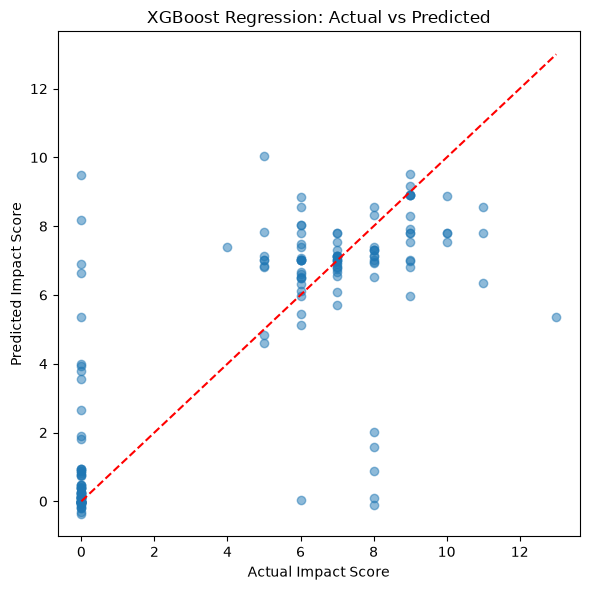

In [15]:
# Fit model
xgbB.fit(X_train_B, y_train_B)

# Predictions
y_pred_B = xgbB.predict(X_test_B)

# Evaluation
mae = mean_absolute_error(y_test_B, y_pred_B)
rmse = mean_squared_error(y_test_B, y_pred_B) ** 0.5
r2 = r2_score(y_test_B, y_pred_B)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

comparison = pd.DataFrame({
    "Actual": y_test_B,
    "Predicted": y_pred_B
})

print(comparison.head(20))

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_B,
    y_pred_B,
    alpha=0.5
)

plt.plot(
    [y_test_B.min(), y_test_B.max()],
    [y_test_B.min(), y_test_B.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Impact Score")
plt.ylabel("Predicted Impact Score")
plt.title("XGBoost Regression: Actual vs Predicted")


plt.tight_layout()
plt.savefig(
    "model_output/impact_score_XGBoost_scatterplot_existing_predictors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

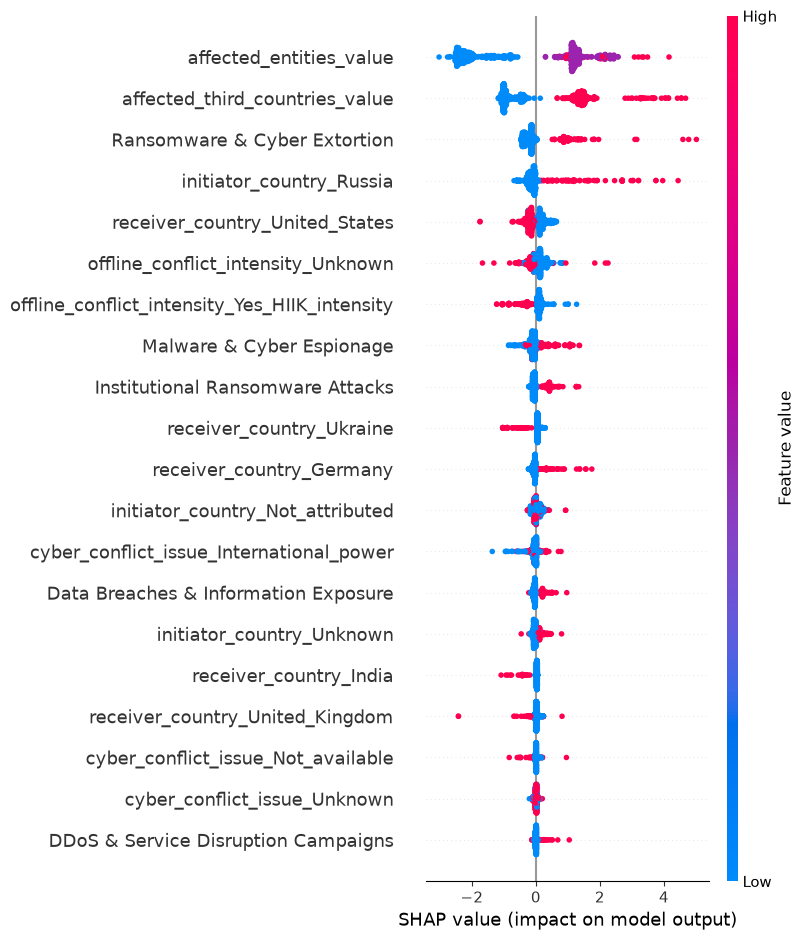

<Figure size 640x480 with 0 Axes>

In [17]:
X_train_B_shap = X_train_B.copy()

topic_rename = {
    "topic_1_0": "Malware & Cyber Espionage",
    "topic_2_0": "Ransomware & Cyber Extortion",
    "topic_3_0": "DDoS & Service Disruption Campaigns",
    "topic_4_0": "Data Breaches & Information Exposure",
    "topic_5_0": "Institutional Ransomware Attacks",
    "topic_6_0": "Vulnerability Exploitation & Theft",
    "topic_7_0": "Surveillance & Mobile Espionage",
    "topic_8_0": "Government Intelligence Operations"
}

X_train_B_shap = X_train_B_shap.rename(
    columns=topic_rename
)

explainer = shap.TreeExplainer(xgbB)

shap_values = explainer.shap_values(
    X_train_B_shap
)

shap.summary_plot(
    shap_values,
    X_train_B_shap
)

plt.tight_layout()

plt.savefig(
    "model_output/impact_score_XGBoost_latent_topic_predictors_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

## Model C: Existing Categories + BERTopics 

In [18]:
existing_lookup = (
    dyadic_data_orig_matched[
        ["incident_id"] + existing_features
    ]
    .drop_duplicates("incident_id")
)

topic_combined = filtered_topic.merge(
    existing_lookup,
    on="incident_id",
    how="left"
)

X_controls = pd.get_dummies(
    topic_combined[control_features],
    drop_first=True
)

X_existing_ops = topic_combined[
    existing_features
]

X_topics = pd.get_dummies(
    topic_combined["topic"],
    prefix="topic",
    drop_first=True
)

X_combined = pd.concat(
    [
        X_controls,
        X_existing_ops,
        X_topics
    ],
    axis=1
)

X_combined.columns = (
    X_combined.columns
    .astype(str)
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# Regression outcome
y = topic_combined["impact_indicator_score"]

In [19]:
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    random_state=99
)

In [20]:
# Define model
xgbC = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=99
)

# 5-fold CV
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=99
)

# Cross-validation
for metric in [
    "neg_mean_absolute_error",
    "neg_root_mean_squared_error",
    "r2"
]:
    scores = cross_val_score(
        xgbC,
        X_train_C,
        y_train_C,
        cv=cv,
        scoring=metric
    )

    print(metric, np.mean(scores))

neg_mean_absolute_error -1.067293155193329
neg_root_mean_squared_error -1.7802716493606567
r2 0.7660719156265259


MAE: 1.105
RMSE: 1.987
R²: 0.731
     Actual  Predicted
262       7   6.512300
316       6   6.731577
667       9   9.486017
749       0   0.119806
436       7   6.694944
22        8  -0.137378
420       7   5.772574
224       7   7.659329
777       6   8.550811
648       6   6.712935
748       0   0.484306
17        0  -0.853476
126       0   0.497182
371       6   6.414784
306       7   6.731577
453       7   6.207170
619       0  -0.049469
100       5   8.274333
799      11   9.982882
48        9   7.748100


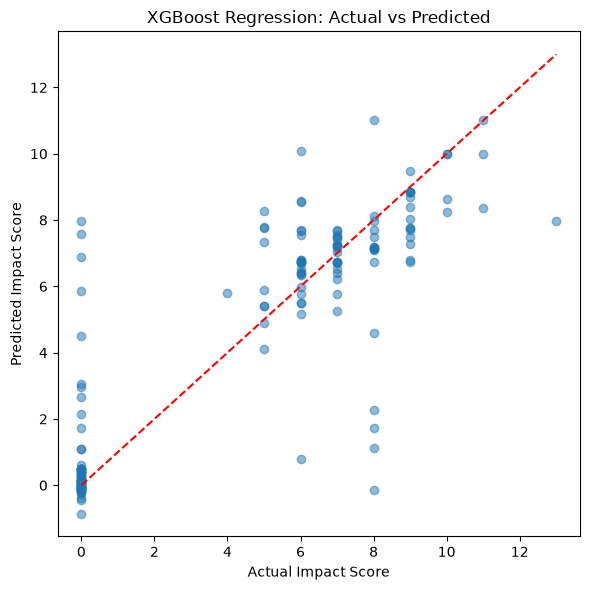

In [21]:
# Fit model
xgbC.fit(X_train_C, y_train_C)

# Predictions
y_pred_C = xgbC.predict(X_test_C)

# Evaluation
mae = mean_absolute_error(y_test_C, y_pred_C)
rmse = mean_squared_error(y_test_C, y_pred_C) ** 0.5
r2 = r2_score(y_test_C, y_pred_C)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

comparison = pd.DataFrame({
    "Actual": y_test_C,
    "Predicted": y_pred_C
})

print(comparison.head(20))

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_C,
    y_pred_C,
    alpha=0.5
)

plt.plot(
    [y_test_C.min(), y_test_C.max()],
    [y_test_C.min(), y_test_C.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Impact Score")
plt.ylabel("Predicted Impact Score")
plt.title("XGBoost Regression: Actual vs Predicted")


plt.tight_layout()
plt.savefig(
    "model_output/impact_score_XGBoost_scatterplot_combined_predictors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

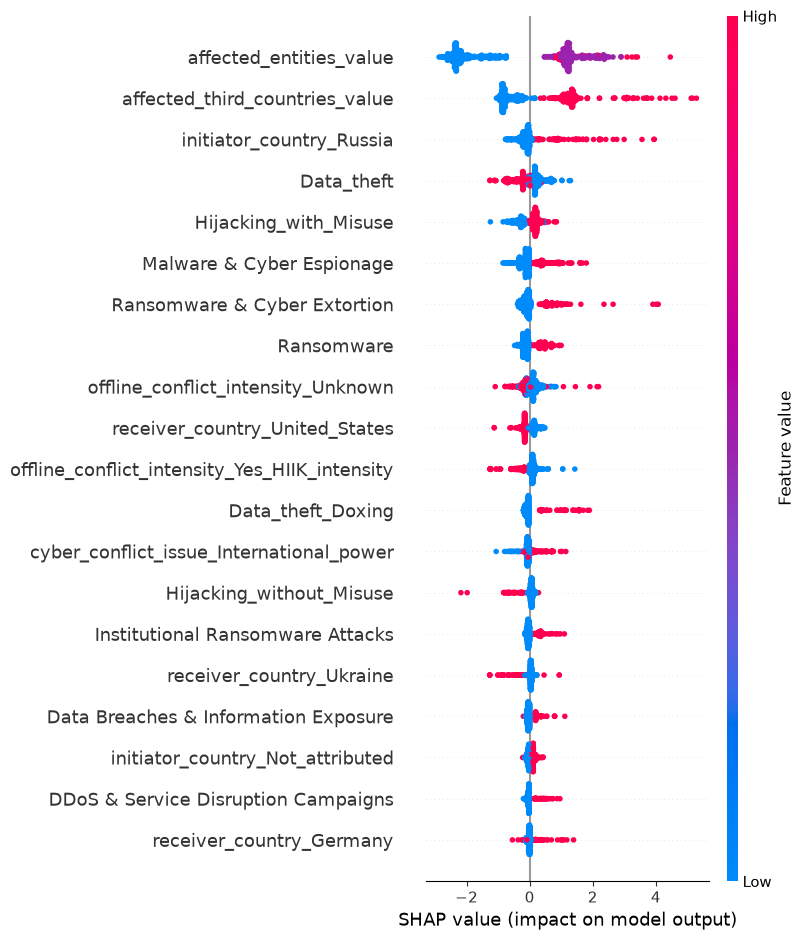

<Figure size 640x480 with 0 Axes>

In [23]:
explainer = shap.TreeExplainer(xgbC)

shap_values = explainer.shap_values(
    X_train_C
)

X_train_C_shap = X_train_C.rename(
    columns=topic_rename
)

shap.summary_plot(
    shap_values,
    X_train_C_shap
)

plt.tight_layout()

plt.savefig(
    "model_output/impact_score_XGBoost_combined_predictors_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

In [24]:
# Evaluate models
models = {
    "Model A": (xgbA, X_test_A, y_test_A),
    "Model B": (xgbB, X_test_B, y_test_B),
    "Model C": (xgbC, X_test_C, y_test_C)
}

results = []

for name, (model, X_test, y_test) in models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": mean_squared_error(
            y_test,
            y_pred
        ) ** 0.5,
        "R²": r2_score(y_test, y_pred)
    })

results_table = (
    pd.DataFrame(results)
    .sort_values("R²", ascending=False)
    .reset_index(drop=True)
)

print(results_table.round(3))

# Save comparison table
results_table.round(3).to_csv(
    "model_output/xgboost_model_comparison.csv",
    index=False
)

with open("model_output/xgbA.pkl", "wb") as f:
    pickle.dump(xgbA, f)

with open("model_output/xgbB.pkl", "wb") as f:
    pickle.dump(xgbB, f)

with open("model_output/xgbC.pkl", "wb") as f:
    pickle.dump(xgbC, f)

     Model    MAE   RMSE     R²
0  Model A  1.052  1.876  0.760
1  Model C  1.105  1.987  0.731
2  Model B  1.336  2.348  0.625


A model using only BERTopic-derived cyber-operation topics explained **62.5% of the variance** in incident impact (R-sqaured = 0.625), demonstrating that unsupervised NLP methods successfully captured meaningful operational characteristics from unstructured text. A model using structured domain variables achieved the strongest performance (R-squared = 0.760), whlie combining structured and latent topic features resulted in slightly lower predictive accuracy (R-squared = 0.731), indicating substantial overlap in the information captured by the two features sets. 

The analysis shows that topic-model derived features can serve as effective representations of cyber incidents, achieving predictive performance comparable to many manually engineered variables. This provided evidence that BERTopic successfully extracted semantically meaningful operational patterns from free-text incident descriptions and transformed them into machine-learning-ready features. 